In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

import joblib

In [23]:
df = pd.read_csv("salary_data.csv")

In [24]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [26]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [27]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

Selecting features and Target

In [28]:
X = df["YearsExperience"]
y = df["Salary"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Linear Regression model

In [30]:
model = LinearRegression()

In [31]:
model.fit(X_train.values.reshape(-1, 1), y_train)

LinearRegression()

In [32]:
y_pred = model.predict(X_test.values.reshape(-1, 1))

Model Evaluation

In [33]:
mse = mean_squared_error(y_test, y_pred)

In [34]:
print(mse)

49830096.85590839


In [35]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results)

      Actual      Predicted
27  112635.0  115790.210113
15   67938.0   71498.278095
23  113812.0  102596.868661
17   83088.0   75267.804224
8    64445.0   55477.792045
9    57189.0   60189.699707


Visualizing  Linear Regression

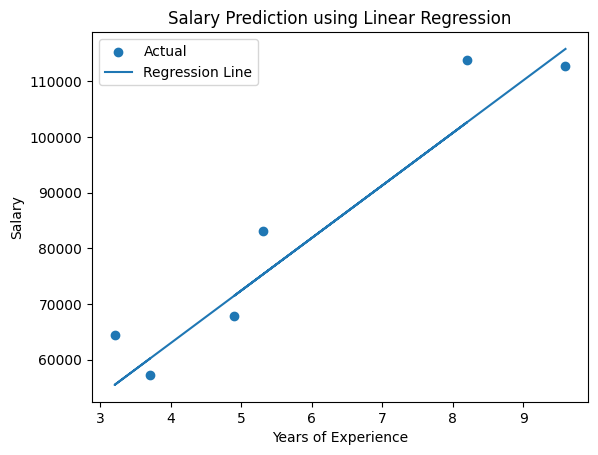

In [36]:
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")
plt.legend()
plt.show()

In [40]:
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [41]:
print("R² Score:", r2)

R² Score: 0.9024461774180497


Save the model in joblib

In [42]:
joblib.dump(model, "salary_prediction_model.pkl")

print("\nModel saved successfully.")



Model saved successfully.
